<a id='intro'></a>
# Introduction

### Dataset Description
    This EGX stock database contains companies, daily trading records, and market indices from the Egyptian Exchange within the specified period.

In [349]:
import pandas as pd
import datetime 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx

In [350]:
import os
df = pd.read_csv(os.path.join('..', 'data', 'raw.csv'))
df2 = pd.read_csv(os.path.join('..', 'data', 'stock_data.csv'))

In [351]:
df.head(10)

,Date,Company,Symbol,MarketCap,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
0,2025-06-01 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,81.750000,82.239998,81.160004,81.160004,424708,0.0,0.0,0.0
1,2025-06-02 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,81.160004,81.879997,80.010002,80.559998,77620,0.0,0.0,0.0
2,2025-06-03 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.559998,80.980003,79.959999,80.110001,136590,0.0,0.0,0.0
3,2025-06-04 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.110001,80.650002,79.910004,80.500000,154041,0.0,0.0,0.0
4,2025-06-10 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.500000,81.209999,80.019997,80.750000,69382,0.0,0.0,0.0
5,2025-06-11 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.750000,81.209999,80.000000,80.209999,92666,0.0,0.0,0.0
6,2025-06-12 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.209999,80.599998,78.500000,78.510002,528845,0.0,0.0,0.0
7,2025-06-15 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,78.510002,77.699997,74.500000,76.599998,163295,0.0,0.0,0.0
8,2025-06-16 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,76.599998,78.000000,76.599998,77.070000,181288,0.0,0.0,0.0
9,2025-06-17 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,77.070000,78.510002,75.500000,75.959999,82074,0.0,0.0,0.0


In [352]:
df2.head()

,Company,Sector,Price,1D,YTD,M.Cap,Date
0,Company,Sector,Price,1D,YTD,M.Cap,Date
1,Abu Dhabi Islamic Bank Egypt,Financials,39.89,-2.47%,+33.41%,47.86,24/03
2,Abu Qir Fertilizers,Basic Materials,94.00,+8.05%,+84.31%,118.61,24/03
3,Acrow Misr,Industrials,127.52,-,+4.64%,7.02,24/03
4,Advanced Pharmaceutical Packaging Co.,Industrials,2.33,-,-,0,24/03


In [353]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4640 entries, 0 to 4639
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           4640 non-null   object 
 1   Company        4640 non-null   object 
 2   Symbol         4640 non-null   object 
 3   MarketCap      4640 non-null   int64  
 4   Open           4640 non-null   float64
 5   High           4640 non-null   float64
 6   Low            4640 non-null   float64
 7   Close          4640 non-null   float64
 8   Volume         4640 non-null   int64  
 9   Dividends      4640 non-null   float64
 10  Stock Splits   4640 non-null   float64
 11  Capital Gains  4640 non-null   float64
dtypes: float64(7), int64(2), object(3)
memory usage: 435.1+ KB


# Cleaning , Fixing Format and Processing The Data :

## Data set 1 :

In [354]:
df.describe()

,MarketCap,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
count,4.640000e+03,4640.000000,4640.000000,4640.000000,4640.000000,4.640000e+03,4640.000000,4640.000000,4640.0
mean,3.742301e+10,28.017820,28.487500,27.719858,28.068615,5.021843e+06,0.001872,0.002922,0.0
std,5.302482e+10,27.041865,27.608807,26.775546,27.153059,1.631203e+07,0.090397,0.068099,0.0
min,9.164430e+08,0.644000,0.649000,0.627000,0.644000,0.000000e+00,0.000000,0.000000,0.0
25%,8.262643e+09,8.180000,8.300000,8.097500,8.187500,3.041320e+05,0.000000,0.000000,0.0
50%,1.932572e+10,19.304999,19.570000,19.135000,19.304999,9.432640e+05,0.000000,0.000000,0.0
75%,4.297567e+10,41.806617,42.607500,41.000000,41.955819,2.833176e+06,0.000000,0.000000,0.0
max,2.683270e+11,161.320007,170.979996,159.009995,170.979996,5.561549e+08,6.000000,3.000000,0.0


In [355]:
df = df.drop(["Capital Gains","Dividends","Stock Splits"],axis=1)
df.columns = df.columns.str.strip()

In [356]:
df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df['Date'] = df['Date'].dt.tz_localize(None) 


In [357]:
df.isna().sum()

Date         0
Company      0
Symbol       0
MarketCap    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64

In [358]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4640 entries, 0 to 4639
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4640 non-null   datetime64[ns]
 1   Company    4640 non-null   object        
 2   Symbol     4640 non-null   object        
 3   MarketCap  4640 non-null   int64         
 4   Open       4640 non-null   float64       
 5   High       4640 non-null   float64       
 6   Low        4640 non-null   float64       
 7   Close      4640 non-null   float64       
 8   Volume     4640 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 326.4+ KB


## Data set 2 :

In [359]:
df2.describe()

,Company,Sector,Price,1D,YTD,M.Cap,Date
count,290,306,306,306,301,284,284
unique,288,33,293,171,217,207,15
top,Misr Chemical Industries,Financials,1.00,-,-,0,24/03
freq,2,90,6,101,65,39,241


In [360]:
SECTORS = [
    'Financials', 'Basic Materials', 'Industrials', 'Consumer Goods',
    'Consumer Services', 'Technology', 'Health Care', 'Utilities', 'Telecom', 'Oil & Gas']

df2 = df2[df2['Sector'].isin(SECTORS)].copy()
df2 = df2.dropna(subset=['Company', 'Sector']).reset_index(drop=True)


In [361]:
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace('%', '', regex=False)
              .str.replace('+', '', regex=False)
              .str.replace(',', '', regex=False)
              .str.strip(),
        errors='coerce'
    )

df2['Price'] = clean_numeric(df2['Price'])
df2['M.Cap'] = clean_numeric(df2['M.Cap'])
df2['1D']    = clean_numeric(df2['1D'])
df2['YTD']   = clean_numeric(df2['YTD'])

In [362]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  283 non-null    object 
 1   Sector   283 non-null    object 
 2   Price    282 non-null    float64
 3   1D       182 non-null    float64
 4   YTD      217 non-null    float64
 5   M.Cap    282 non-null    float64
 6   Date     282 non-null    object 
dtypes: float64(4), object(3)
memory usage: 15.6+ KB


## Exploring  :

### formals we will use 

    Range stock prices = (high - low )/ close  
    Period Return (%) = [(Closing Price − Opening Price) ÷ Opening Price] × 100

    Price vs High = ( Close - HighW ) / High × 100
    Price vs Low = ( Close - Low ) / Low × 100

    Portfolio Value =  start × pi (1 + r_t)
    Total Gain = Portfolio Value − start


In [363]:
df['Price_Range']     = (df['High'] - df['Low']) / df['Close']
df['Period_Return']   = ((df['Close'] - df['Open']) / df['Open']) * 100 

In [364]:
df = df.sort_values(['Company', 'Date'])

df = df.set_index('Date')

# Calculate 365D rolling High/Low per company
df['High_365'] = df.groupby('Company')['High'].transform(
    lambda x: x.rolling('365D', min_periods=1).max()
)

df['Low_365'] = df.groupby('Company')['Low'].transform(
    lambda x: x.rolling('365D', min_periods=1).min()
)

# Price vs 365 High/Low %
df['Price_vs_365_High'] = ((df['Close'] - df['High_365']) / df['High_365']) * 100
df['Price_vs_365_Low']  = ((df['Close'] - df['Low_365']) / df['Low_365']) * 100

# Optional: bring Date back as column
df = df.reset_index()

In [365]:
df = df.sort_values(['Company', 'Date']).reset_index(drop=True)

df['Daily_Return '] = df.groupby('Company')['Close'].pct_change()

start = 10_000


df['Portfolio_Value'] = df.groupby('Company')['Daily_Return '].transform(
    lambda r: start * (1 + r.fillna(0)).cumprod()
)

df['Total_Gain'] = df['Portfolio_Value'] - start

df

,Date,Company,Symbol,MarketCap,Open,High,Low,Close,Volume,Price_Range,Period_Return,High_365,Low_365,Price_vs_365_High,Price_vs_365_Low,Daily_Return,Portfolio_Value,Total_Gain
0,2025-05-31 21:00:00,Abu Kir Fertilizers,ABUK.CA,73592594432,42.918101,43.379968,42.802633,42.989159,583557,0.013430,0.165567,43.379968,42.802633,-0.900898,0.435781,NaN,10000.000000,0.000000
1,2025-06-01 21:00:00,Abu Kir Fertilizers,ABUK.CA,73592594432,42.989157,43.921773,43.077977,43.522079,648049,0.019388,1.239666,43.921773,42.802633,-0.910012,1.680847,0.012397,10123.966333,123.966333
2,2025-06-02 21:00:00,Abu Kir Fertilizers,ABUK.CA,73592594432,43.522078,43.939536,43.548723,43.602016,379774,0.008963,0.183674,43.939536,42.802633,-0.768144,1.867604,0.001837,10142.561017,142.561017
3,2025-06-03 21:00:00,Abu Kir Fertilizers,ABUK.CA,73592594432,43.602020,44.312584,43.495436,44.312584,592659,0.018441,1.629658,44.312584,42.802633,0.000000,3.527706,0.016297,10307.850941,307.850941
4,2025-06-09 21:00:00,Abu Kir Fertilizers,ABUK.CA,73592594432,44.312582,45.174142,44.339227,45.085320,1118897,0.018519,1.743834,45.174142,42.802633,-0.196623,5.333052,0.017438,10487.602213,487.602213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4635,2025-12-24 22:00:00,Unit Investments,UNIT.CA,1450209408,10.930000,11.300000,10.950000,11.220000,282815,0.031194,2.653248,12.000000,6.850000,-6.499998,63.795627,0.026532,14514.877412,4514.877412
4636,2025-12-27 22:00:00,Unit Investments,UNIT.CA,1450209408,11.220000,11.350000,11.000000,11.160000,152068,0.031362,-0.534763,12.000000,6.850000,-7.000001,62.919708,-0.005348,14437.257206,4437.257206
4637,2025-12-28 22:00:00,Unit Investments,UNIT.CA,1450209408,11.160000,11.250000,10.600000,11.060000,244465,0.058770,-0.896052,12.000000,6.850000,-7.833330,61.459862,-0.008961,14307.891840,4307.891840
4638,2025-12-29 22:00:00,Unit Investments,UNIT.CA,1450209408,11.060000,11.180000,10.760000,10.940000,159383,0.038391,-1.084999,12.000000,6.850000,-8.833337,59.708025,-0.010850,14152.651427,4152.651427


##  Visualization :

In [366]:
# Create a dictionary mapping Company to Sector from df2
sector_map = df2.drop_duplicates('Company').set_index('Company')['Sector'].to_dict()

# Add Sector column to df
df['Sector'] = df['Company'].map(sector_map)


In [367]:
# Create empty graph
G_sector = nx.Graph()

# Get unique sectors (remove NaN)
sectors = df['Sector'].dropna().unique()

# Add nodes and edges for each sector
for sector in sectors:
    # Get companies in this sector
    companies = df[df['Sector'] == sector]['Company'].unique()
    
    # Add each company as a node
    for company in companies:
        G_sector.add_node(company, sector=sector)
    
    # Connect companies in same sector
    for i in range(len(companies)):
        for j in range(i + 1, len(companies)):
            G_sector.add_edge(companies[i], companies[j])

print(f"Total nodes: {G_sector.number_of_nodes()}")
print(f"Total edges: {G_sector.number_of_edges()}")

Total nodes: 14
Total edges: 12


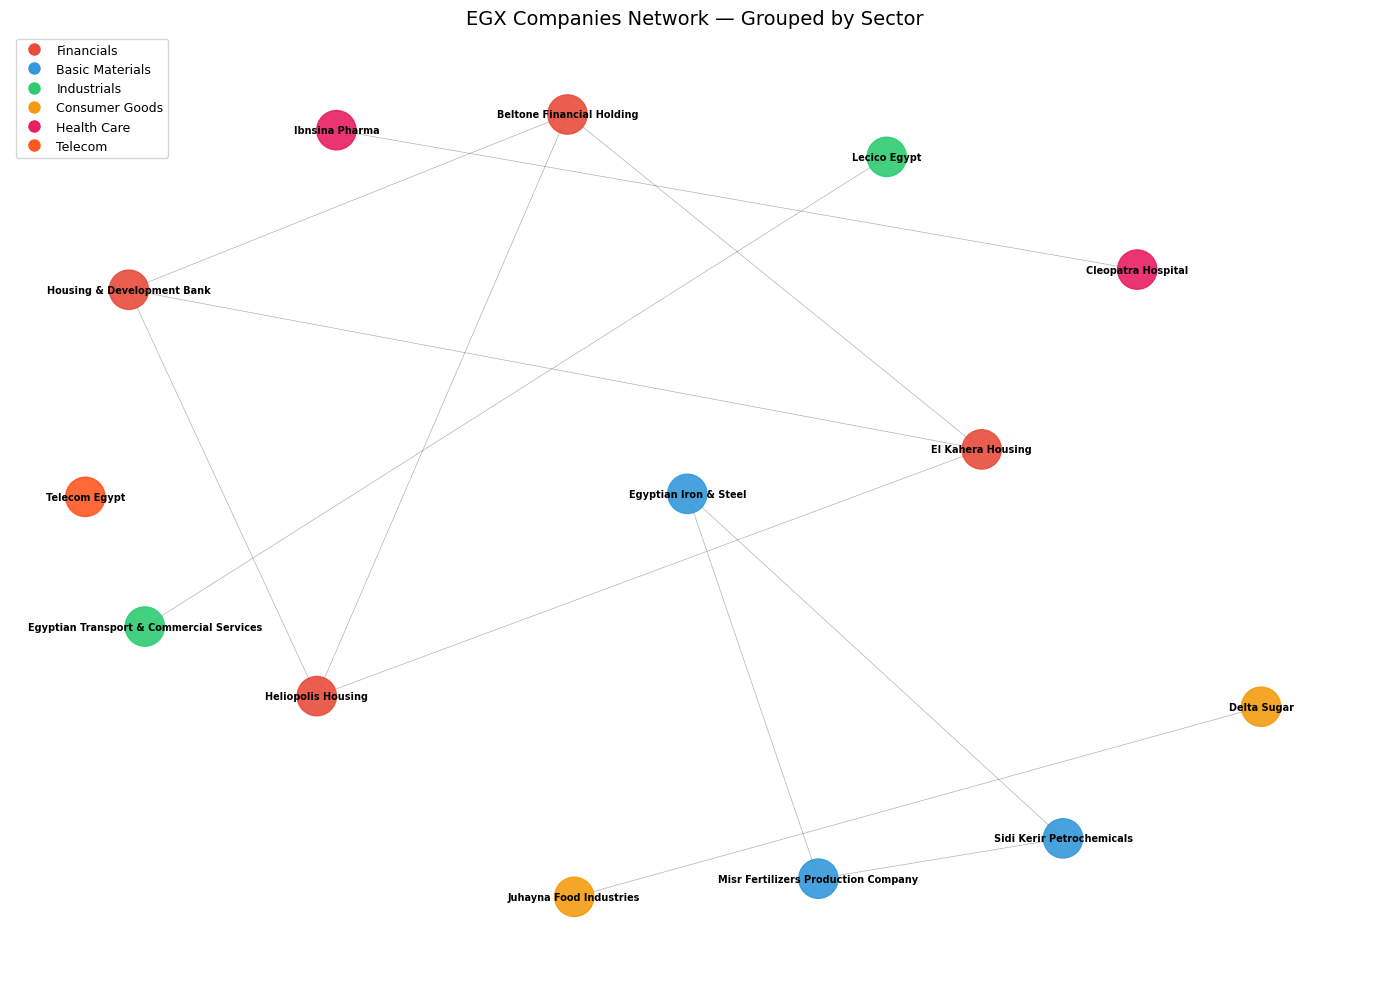

In [368]:
# Define colors for each sector
sector_colors = {
    'Financials': '#e74c3c',
    'Basic Materials': '#3498db',
    'Industrials': '#2ecc71',
    'Consumer Goods': '#f39c12',
    'Consumer Services': '#9b59b6',
    'Technology': '#1abc9c',
    'Health Care': '#e91e63',
    'Utilities': '#00bcd4',
    'Telecom': '#ff5722',
    'Oil & Gas': '#795548'
}

# Assign color to each node
node_colors = []
for node in G_sector.nodes():
    sector = G_sector.nodes[node].get('sector', '')
    color = sector_colors.get(sector, '#95a5a6')
    node_colors.append(color)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Calculate positions
pos = nx.spring_layout(G_sector, k=2, iterations=50, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G_sector, pos, ax=ax, 
                       node_color=node_colors, 
                       node_size=800, 
                       alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G_sector, pos, ax=ax,
                       edge_color="#000000",
                       width=0.5,
                       alpha=0.3)

# Draw labels
nx.draw_networkx_labels(G_sector, pos, ax=ax,
                        font_size=7,
                        font_weight='bold')

# Create legend
legend_list = []
for sector, color in sector_colors.items():
    if sector in df['Sector'].dropna().unique():
        line = plt.Line2D([0], [0], marker='o', color='w', 
                         markerfacecolor=color, markersize=10, label=sector)
        legend_list.append(line)

ax.legend(handles=legend_list, loc='upper left', fontsize=9)
ax.set_title('EGX Companies Network — Grouped by Sector', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [369]:
sector_daily = df.groupby('Sector')['Daily_Return '].mean()
 
sector_ytd = df2.groupby('Sector')['YTD'].mean()

comparison = pd.DataFrame({
    'Daily_Return': sector_daily,
    'YTD_Return': sector_ytd
})

comparison = comparison.dropna()
comparison = comparison.sort_values('Daily_Return')

print(comparison)

                 Daily_Return  YTD_Return
Sector                                   
Consumer Goods      -0.000383   -4.469750
Basic Materials     -0.000367    8.291429
Financials          -0.000268   -0.232639
Industrials          0.000130   13.429706
Health Care          0.002758    0.167778
Telecom              0.004235   35.228000


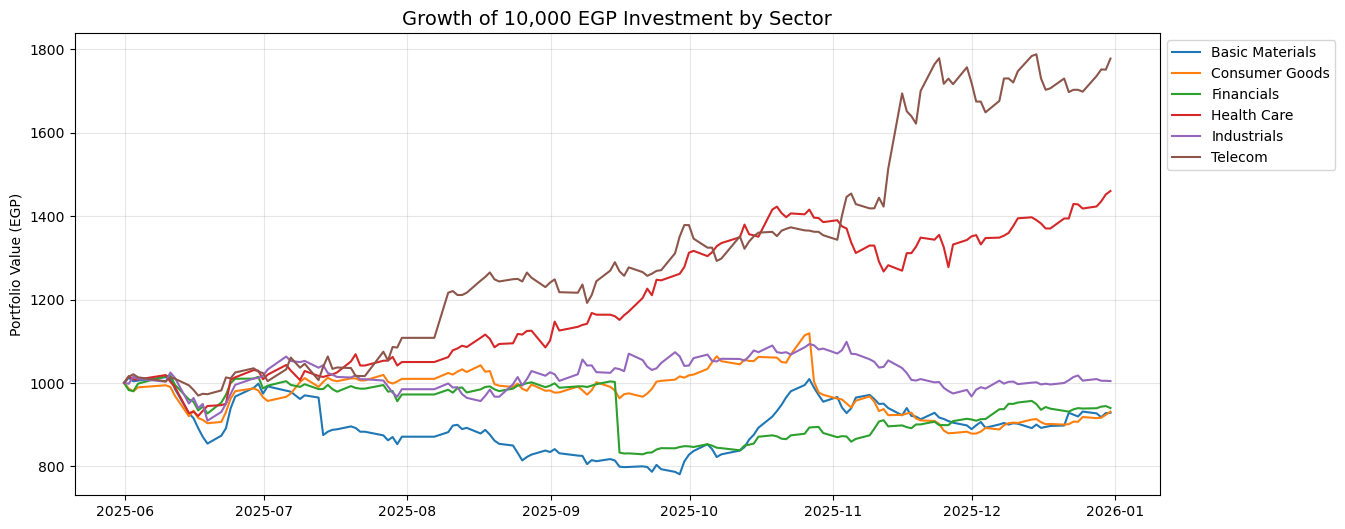

In [370]:

sector_stats = df.groupby('Sector').agg(
    Avg_Daily_Return=('Daily_Return ', 'mean'),
    Volatility=('Daily_Return ', 'std'),
    Total_Volume=('Volume', 'sum')
).reset_index()

sector_mcap = df2.groupby('Sector')['M.Cap'].sum().reset_index()
sector_stats = sector_stats.merge(sector_mcap, on='Sector')

# 2. Cumulative Performance (Growth of 10,000 EGP)
sector_daily_returns = df.groupby(['Date', 'Sector'])['Daily_Return '].mean().reset_index()
sector_pivot = sector_daily_returns.pivot(index='Date', columns='Sector', values='Daily_Return ')


initial_investment = int(input('enter the number  to invest :'))
sector_cumulative = initial_investment * (1 + sector_pivot.fillna(0)).cumprod()

plt.figure(figsize=(14, 6))
for sector in sector_cumulative.columns:
    plt.plot(sector_cumulative.index, sector_cumulative[sector], label=sector)
plt.title('Growth of 10,000 EGP Investment by Sector', fontsize=14)
plt.ylabel('Portfolio Value (EGP)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1)
plt.grid(True, alpha=0.3)
plt.show()



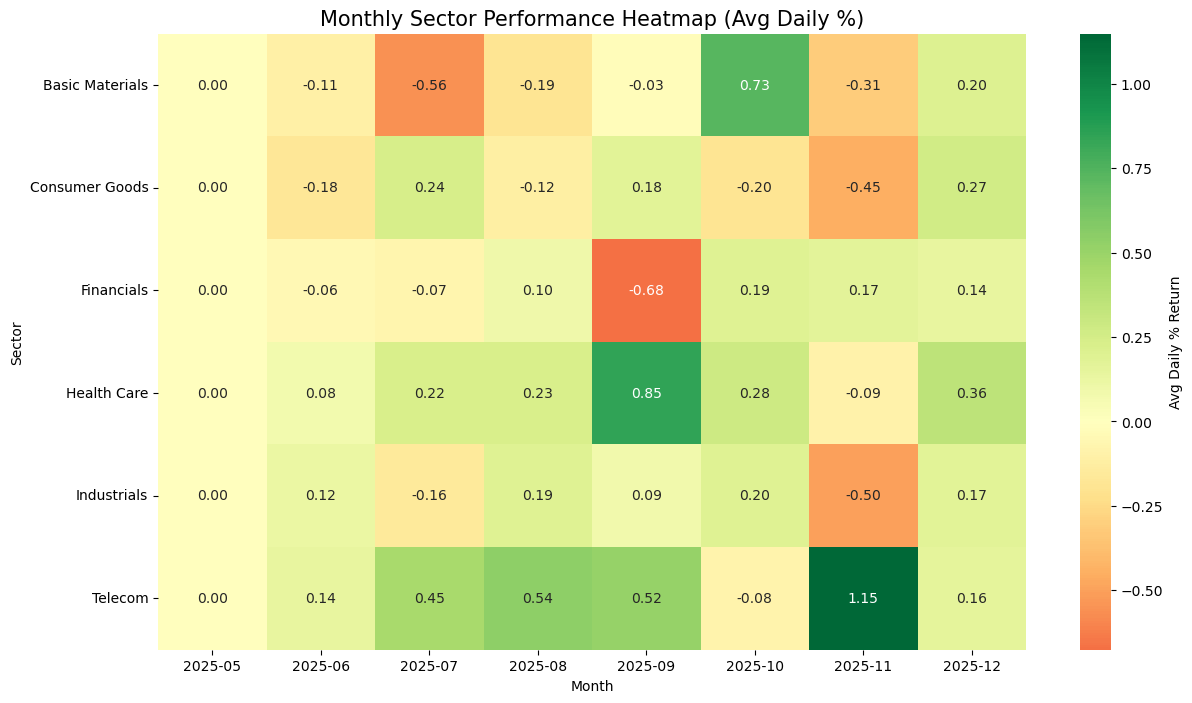

In [371]:

df['Month'] = df['Date'].dt.to_period('M')
monthly_sector_returns = df.groupby(['Month', 'Sector'])['Daily_Return '].mean().unstack().fillna(0)
monthly_sector_returns.index = monthly_sector_returns.index.astype(str) # Convert to string for plotting

plt.figure(figsize=(14, 8))

sns.heatmap(monthly_sector_returns.T * 100, annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, cbar_kws={'label': 'Avg Daily % Return'})
plt.title('Monthly Sector Performance Heatmap (Avg Daily %)', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Sector')
plt.show()

In [372]:

pivot_returns = df.pivot_table(
    values='Daily_Return ', 
    index='Date', 
    columns='Company'
)

print(f"Pivot table shape: {pivot_returns.shape}")
print(f"Number of companies: {len(pivot_returns.columns)}")

pivot_returns.head()

Pivot table shape: (144, 32)
Number of companies: 32


Company,Abu Kir Fertilizers,Alexandria Container & Cargo Handling,Alexandria Mineral Oils,Beltone Financial Holding,CIB Egypt,Cairo Poultry (Koki),Cleopatra Hospital,Commercial International Bank (CIB),Delta Sugar,Egyptian Electrical Cables,...,Misr Fertilizers Production Company,Modern Furniture,Orascom Construction,Orascom Telecom Media & Technology,Palm Hills Developments,Raya Holding,Sidi Kerir Petrochemicals,Talaat Moustafa Group,Telecom Egypt,Unit Investments
Date,,,,,,,,,,,,,,,,,,,,,
2025-06-01 21:00:00,0.012397,0.006557,0.000000,-0.009740,-0.001690,-0.031579,0.009709,-0.003596,-0.024668,0.003676,...,0.005587,-0.009950,-0.014853,-0.006329,-0.005006,-0.003636,-0.004500,-0.008787,0.014865,-0.021992
2025-06-02 21:00:00,0.001837,-0.001086,0.004027,-0.032787,-0.001693,0.008979,-0.001202,0.007964,-0.026265,0.007326,...,-0.002116,0.010050,-0.014462,0.010464,0.011321,0.021898,-0.000502,0.009929,0.005859,0.027778
2025-06-03 21:00:00,0.016297,0.000000,0.001337,0.061017,0.000000,-0.035129,-0.004813,0.010988,0.006394,-0.003636,...,0.001591,-0.004975,0.008430,0.007204,0.023632,0.021429,0.005025,0.002809,-0.007149,0.021879
2025-06-09 21:00:00,0.017438,-0.003261,0.009346,0.035144,0.005088,-0.009223,0.002418,-0.012089,0.002581,0.007299,...,0.016411,0.021250,-0.002322,0.032633,0.041312,0.013986,0.008000,0.024160,-0.009333,0.013854
2025-06-10 21:00:00,-0.006107,0.025082,-0.002645,0.018519,0.012373,-0.013719,-0.019300,0.020396,-0.001386,-0.007246,...,0.002604,0.028152,-0.006982,0.004762,-0.008168,0.044828,-0.000992,-0.013675,0.009421,-0.006211


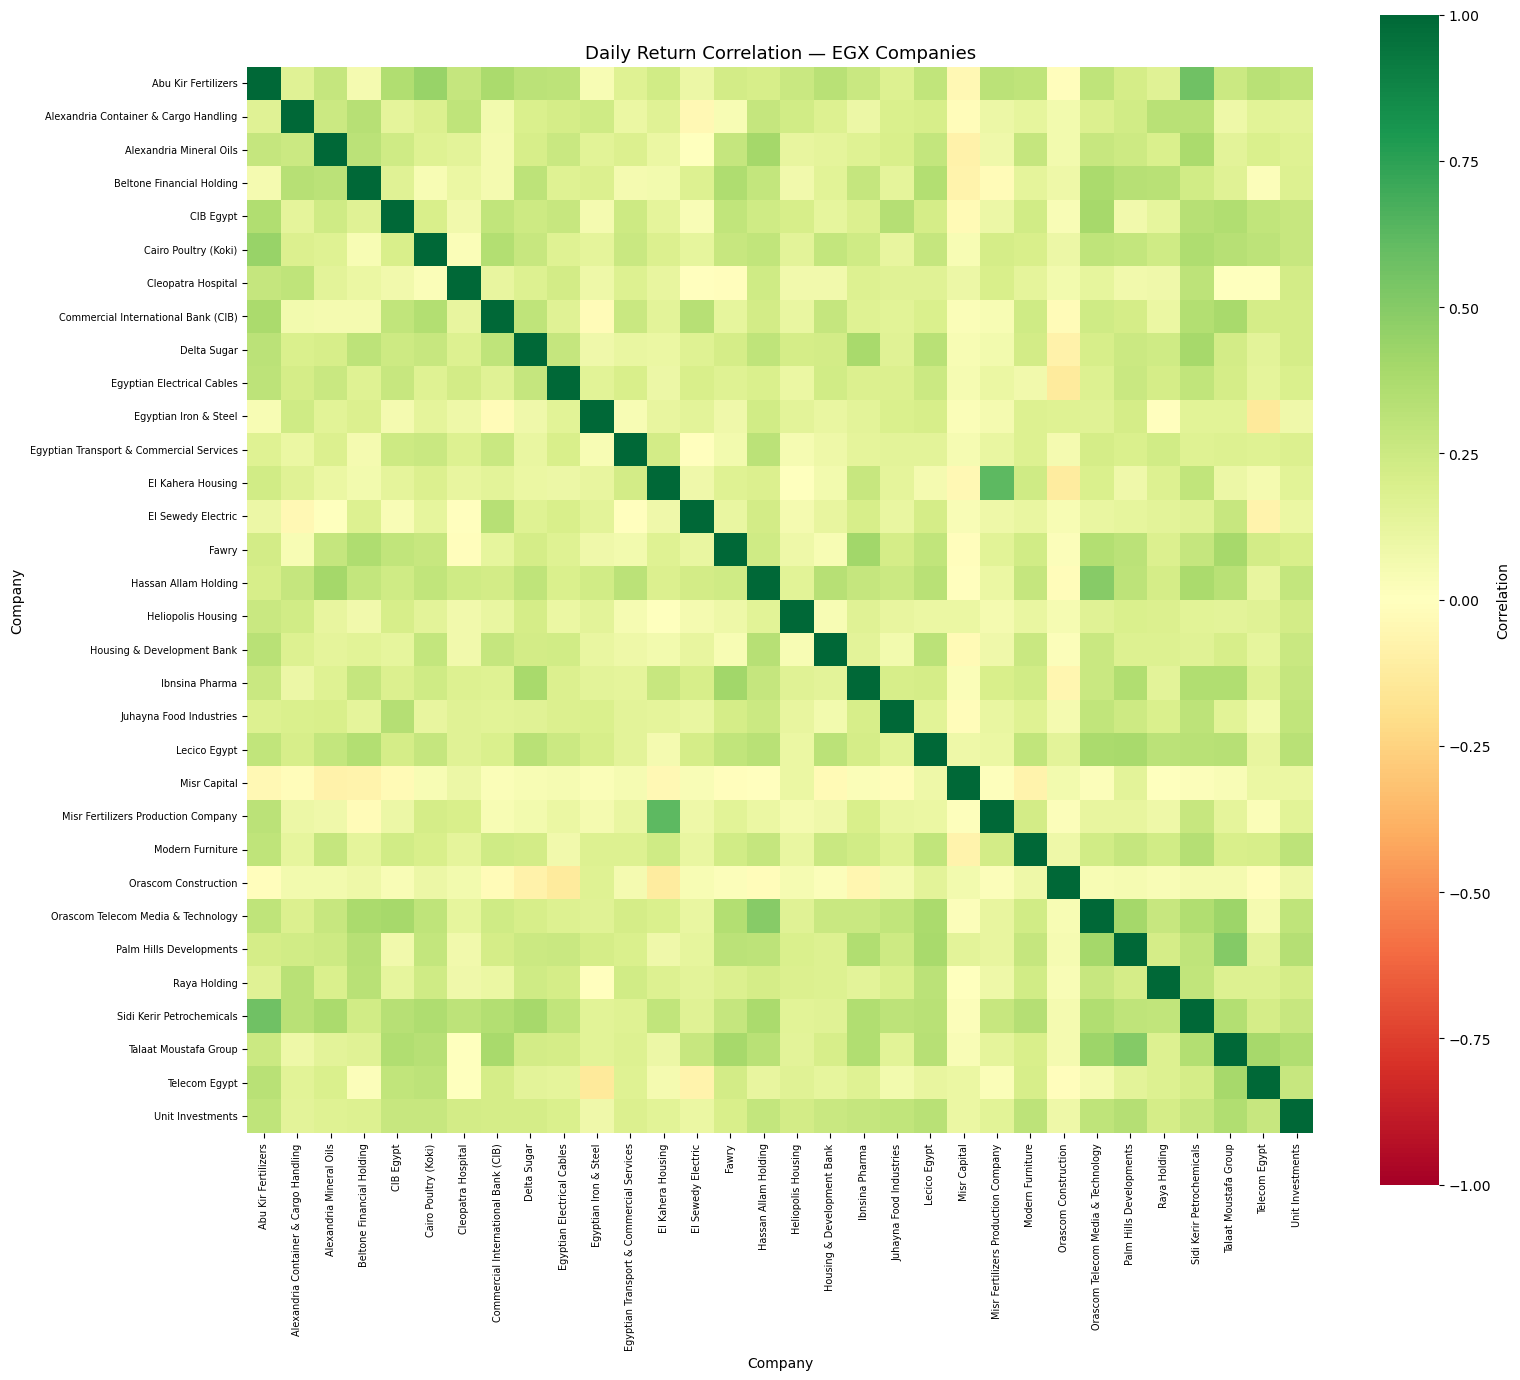

In [373]:

correlation_matrix = pivot_returns.corr()

fig, ax = plt.subplots(figsize=(16, 14))


sns.heatmap(correlation_matrix, 
            cmap='RdYlGn', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            ax=ax,
            xticklabels=True, 
            yticklabels=True,
            square=True,
            cbar_kws={'label': 'Correlation'})

ax.set_title('Daily Return Correlation — EGX Companies', fontsize=13)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()